# Profiler View

Notebook para analizar consumo de recursos y escalado con `timesteps`.
Foco: separar claramente **memoria** (GB) y **tiempo** (s), y comparar FP32 vs AMP en A5000.


## Como se mide (`trace`) y en que unidades se muestra

- El `trace` del profiler registra eventos de CPU/GPU y memoria durante la corrida.
- En el CSV original muchos tiempos vienen en **ms**.
- En este notebook, los tiempos se convierten a **segundos** (`s`) con: `segundos = ms / 1000`.

Que se observa:
- **Memoria (GB)**: `max_alloc_gb_trace`, `max_reserved_gb_trace`.
- **Tiempo de train/eval (s)**: `train_*`, `eval_*` convertidos desde ms.
- **Tiempo agregado CPU/GPU (s)**: `cpu_op_ms_trace`, `gpu_total_ms_trace` convertidos a s.

Aclaracion: `eval_with_f1` / `eval_no_f1` representan **costo temporal** de evaluacion, no memoria.


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.frameon": False,
    "grid.alpha": 0.18,
})

PALETTE = {False: "#1f77b4", True: "#ff7f0e"}
AMP_LABELS = {False: "FP32", True: "AMP"}


In [127]:
csv_path = Path("profiler_runs_summary_3.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"CSV no encontrado en {csv_path}")

df = pd.read_csv(csv_path)
print(f"CSV: {csv_path}")
print(f"rows={len(df)} cols={len(df.columns)}")


CSV: profiler_runs_summary_3.csv
rows=42 cols=48


In [128]:
# Tipado base
num_cols = [
    "timesteps", "batch_size", "oom_events",
    "max_alloc_gb_trace", "max_reserved_gb_trace",
    "train_batch_ms", "train_forward_ms", "train_backward_ms",
    "eval_no_f1_ms", "eval_with_f1_ms", "eval_sample_ms",
    "cpu_op_ms_trace", "gpu_total_ms_trace",
    "train_forward_cpu_ms_keyavg", "train_forward_cuda_ms_keyavg",
    "train_backward_cpu_ms_keyavg", "train_backward_cuda_ms_keyavg",
    "train_forward_alloc_avg_mb_gpu", "train_forward_alloc_peak_mb_gpu",
    "train_backward_alloc_avg_mb_gpu", "train_backward_alloc_peak_mb_gpu",
    "train_step_alloc_avg_mb_gpu", "train_step_alloc_peak_mb_gpu",
    "train_forward_alloc_avg_mb_cpu", "train_forward_alloc_peak_mb_cpu",
    "train_backward_alloc_avg_mb_cpu", "train_backward_alloc_peak_mb_cpu",
    "train_step_alloc_avg_mb_cpu", "train_step_alloc_peak_mb_cpu",
    "train_forward_alloc_delta_avg_mb_gpu", "train_forward_alloc_delta_peak_mb_gpu",
    "train_backward_alloc_delta_avg_mb_gpu", "train_backward_alloc_delta_peak_mb_gpu",
    "train_step_alloc_delta_avg_mb_gpu", "train_step_alloc_delta_peak_mb_gpu",
    "train_forward_alloc_delta_avg_mb_cpu", "train_forward_alloc_delta_peak_mb_cpu",
    "train_backward_alloc_delta_avg_mb_cpu", "train_backward_alloc_delta_peak_mb_cpu",
    "train_step_alloc_delta_avg_mb_cpu", "train_step_alloc_delta_peak_mb_cpu",
]
for c in num_cols:
    if c not in df.columns:
        df[c] = np.nan
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["use_amp"] = (
    df["use_amp"].astype(str).str.strip().str.lower().map({"true": True, "false": False})
)

df["is_oom"] = df["oom_events"].fillna(0) > 0

def ms_to_s(s):
    return s / 1000.0

# Tiempos globales en segundos
for src, dst in [
    ("train_batch_ms", "train_batch_s"),
    ("train_forward_ms", "train_forward_s"),
    ("train_backward_ms", "train_backward_s"),
    ("eval_no_f1_ms", "eval_no_f1_s"),
    ("eval_with_f1_ms", "eval_with_f1_s"),
    ("eval_sample_ms", "eval_sample_s"),
    ("cpu_op_ms_trace", "cpu_op_s_trace"),
    ("gpu_total_ms_trace", "gpu_total_s_trace"),
    ("train_forward_cpu_ms_keyavg", "train_forward_cpu_s_keyavg"),
    ("train_forward_cuda_ms_keyavg", "train_forward_cuda_s_keyavg"),
    ("train_backward_cpu_ms_keyavg", "train_backward_cpu_s_keyavg"),
    ("train_backward_cuda_ms_keyavg", "train_backward_cuda_s_keyavg"),
]:
    df[dst] = ms_to_s(df[src])

df["cpu_gpu_ratio"] = df["cpu_op_s_trace"] / df["gpu_total_s_trace"]
df["cpu_gpu_ratio"] = df["cpu_gpu_ratio"].replace([np.inf, -np.inf], np.nan)

df = df.sort_values(["timesteps", "use_amp"], na_position="last").reset_index(drop=True)

print(df[["run_name", "timesteps", "use_amp", "status", "oom_events"]].head(8))


                  run_name  timesteps  use_amp   status  oom_events
0   sim90_bs4_pb4_5ts_fp32          5    False       ok         0.0
1    sim90_bs4_pb4_5ts_amp          5     True       ok         0.0
2       sim90_bs4_pb4_10ts         10    False  unknown         0.0
3  sim90_bs4_pb4_10ts_fp32         10    False       ok         0.0
4   sim90_bs4_pb4_10ts_amp         10     True       ok         0.0
5  sim90_bs4_pb4_15ts_fp32         15    False       ok         0.0
6   sim90_bs4_pb4_15ts_amp         15     True       ok         0.0
7       sim90_bs4_pb4_25ts         25    False  unknown         0.0


## Seccion 1 - Analisis Global


In [129]:
A5000_GB = 23.68
A5000_80 = 0.80 * A5000_GB
A5000_85 = 0.85 * A5000_GB
A5000_90 = 0.90 * A5000_GB
A5000_100 = A5000_GB


def _label_amp_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    mapped = [AMP_LABELS[False] if l == "False" else AMP_LABELS[True] if l == "True" else l for l in labels]
    ax.legend(handles, mapped, loc="best")


def add_a5000_memory_guides(ax):
    guides = [
        (A5000_80, "80% A5000", "#9aa0a6"),
        (A5000_85, "85% A5000", "#6b7280"),
        (A5000_90, "90% A5000", "#374151"),
        (A5000_100, "100% A5000", "#b91c1c"),
    ]
    for y, label, color in guides:
        ax.axhline(y=y, linestyle="--", linewidth=1.0, color=color, alpha=0.8)
        ax.text(
            0.2,
            y,
            f" {label} ({y:.2f} GB)",
            color=color,
            ha="right",
            va="bottom",
            transform=ax.get_yaxis_transform(),
            fontsize=9,
        )


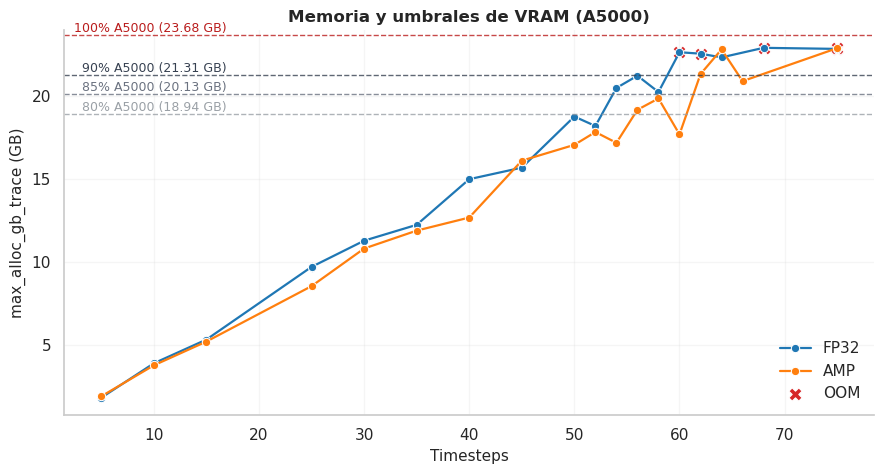

In [130]:
mem_df = df.dropna(subset=["timesteps", "max_alloc_gb_trace", "use_amp"]).copy()
fig, ax = plt.subplots(figsize=(9, 4.9))

sns.lineplot(
    data=mem_df,
    x="timesteps",
    y="max_alloc_gb_trace",
    hue="use_amp",
    palette=PALETTE,
    marker="o",
    linewidth=1.6,
    ax=ax,
)

oom_df = mem_df[mem_df["is_oom"]]
if len(oom_df):
    sns.scatterplot(
        data=oom_df,
        x="timesteps",
        y="max_alloc_gb_trace",
        color="#d62728",
        marker="X",
        s=90,
        label="OOM",
        ax=ax,
    )

add_a5000_memory_guides(ax)
_label_amp_legend(ax)
ax.set_title("Memoria y umbrales de VRAM (A5000)")
ax.set_xlabel("Timesteps")
ax.set_ylabel("max_alloc_gb_trace (GB)")
plt.tight_layout()
plt.show()


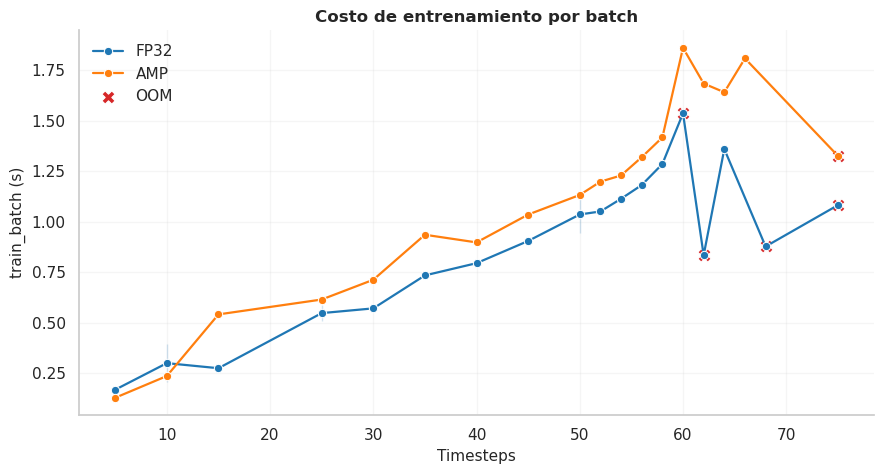

In [131]:
train_df = df.dropna(subset=["timesteps", "train_batch_s", "use_amp"]).copy()
fig, ax = plt.subplots(figsize=(9, 4.9))

sns.lineplot(
    data=train_df,
    x="timesteps",
    y="train_batch_s",
    hue="use_amp",
    palette=PALETTE,
    marker="o",
    linewidth=1.6,
    ax=ax,
)

oom_train = train_df[train_df["is_oom"]]
if len(oom_train):
    sns.scatterplot(
        data=oom_train,
        x="timesteps",
        y="train_batch_s",
        color="#d62728",
        marker="X",
        s=90,
        label="OOM",
        ax=ax,
    )

_label_amp_legend(ax)
ax.set_title("Costo de entrenamiento por batch")
ax.set_xlabel("Timesteps")
ax.set_ylabel("train_batch (s)")
plt.tight_layout()
plt.show()


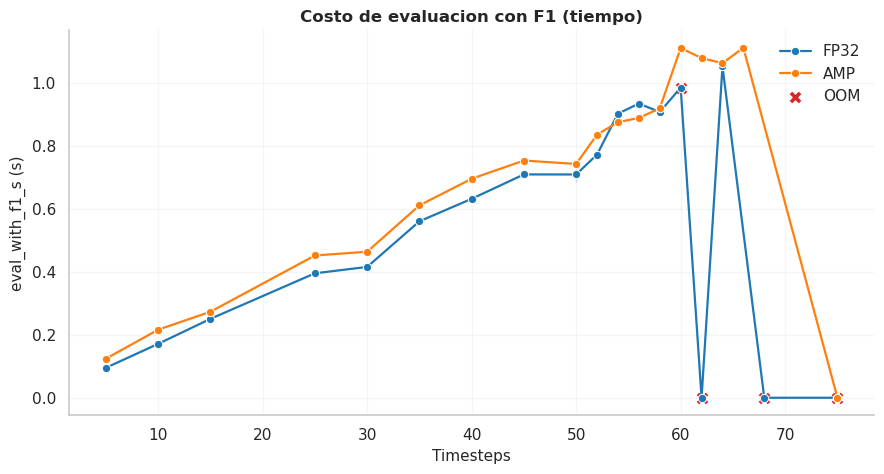

In [ ]:
eval_df = df.dropna(subset=["timesteps", "eval_with_f1_s", "use_amp"]).copy()
fig, ax = plt.subplots(figsize=(9, 4.9))

sns.lineplot(
    data=eval_df,
    x="timesteps",
    y="eval_with_f1_s",
    hue="use_amp",
    palette=PALETTE,
    marker="o",
    linewidth=1.6,
    ax=ax,
)

oom_eval = eval_df[eval_df["is_oom"]]
if len(oom_eval):
    sns.scatterplot(
        data=oom_eval,
        x="timesteps",
        y="eval_with_f1_s",
        color="#d62728",
        marker="X",
        s=90,
        label="OOM",
        ax=ax,
    )

_label_amp_legend(ax)
ax.set_title("Costo de evaluacion con F1 (tiempo)")
ax.set_xlabel("Timesteps")
ax.set_ylabel("eval_with_f1 (s)")
plt.tight_layout()
plt.show()


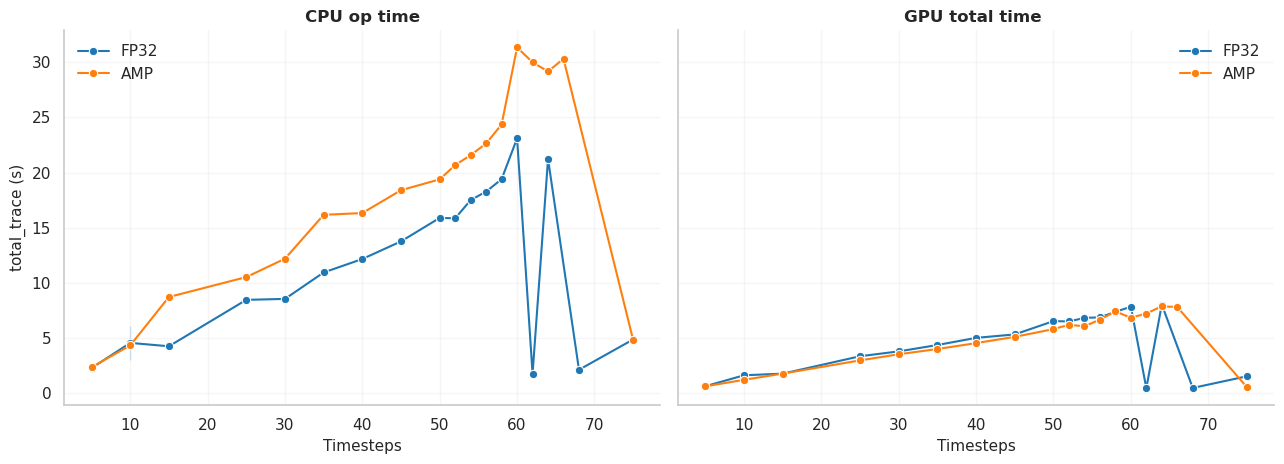

In [148]:
cpu_gpu_df = df.dropna(subset=["timesteps", "cpu_op_s_trace", "gpu_total_s_trace", "use_amp"]).copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True)

sns.lineplot(
    data=cpu_gpu_df,
    x="timesteps",
    y="cpu_op_s_trace",
    hue="use_amp",
    palette=PALETTE,
    marker="o",
    linewidth=1.5,
    ax=axes[0],
)
axes[0].set_title("CPU op time")
axes[0].set_xlabel("Timesteps")
axes[0].set_ylabel("total_trace (s)")
_label_amp_legend(axes[0])

sns.lineplot(
    data=cpu_gpu_df,
    x="timesteps",
    y="gpu_total_s_trace",
    hue="use_amp",
    palette=PALETTE,
    marker="o",
    linewidth=1.5,
    ax=axes[1],
)
axes[1].set_title("GPU total time ")
axes[1].set_xlabel("Timesteps")
axes[1].set_ylabel("total_trace (s)")
_label_amp_legend(axes[1])

plt.tight_layout()
plt.show()


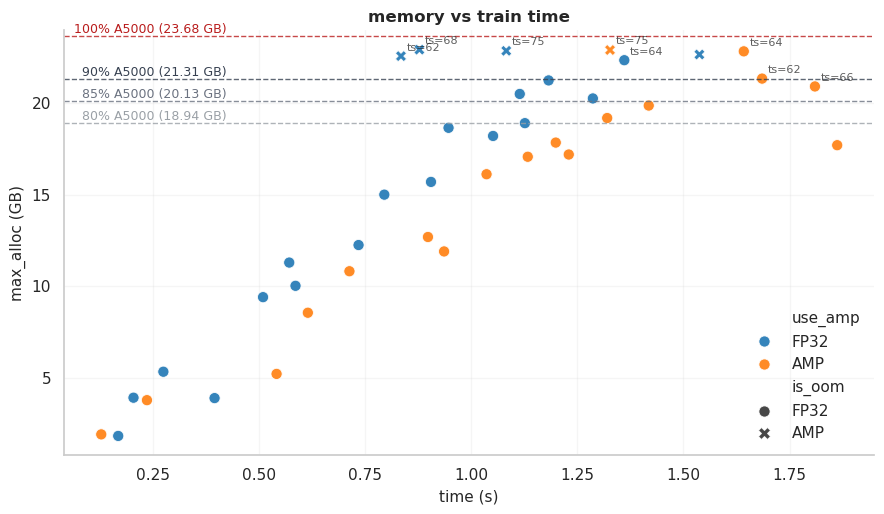

In [150]:
scatter_df = df.dropna(subset=["max_alloc_gb_trace", "train_batch_s", "use_amp"]).copy()
fig, ax = plt.subplots(figsize=(9, 5.3))

sns.scatterplot(
    data=scatter_df,
    x="train_batch_s",
    y="max_alloc_gb_trace",
    hue="use_amp",
    style="is_oom",
    markers={False: "o", True: "X"},
    palette=PALETTE,
    s=65,
    alpha=0.9,
    ax=ax,
)

add_a5000_memory_guides(ax)

high_ts = scatter_df.dropna(subset=["timesteps"]).sort_values("timesteps").tail(8)
for _, r in high_ts.iterrows():
    ax.annotate(
        f"ts={int(r['timesteps'])}",
        (r["train_batch_s"], r["max_alloc_gb_trace"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
        alpha=0.75,
    )

_label_amp_legend(ax)
ax.set_title("memory vs train time")
ax.set_xlabel("time (s)")
ax.set_ylabel("max_alloc (GB)")
plt.tight_layout()
plt.show()


In [135]:
global_cols = [
    "run_name", "timesteps", "use_amp", "status", "oom_events",
    "max_alloc_gb_trace", "train_batch_s", "eval_with_f1_s",
    "cpu_op_s_trace", "gpu_total_s_trace", "cpu_gpu_ratio",
]
display(df[global_cols].sort_values(["timesteps", "use_amp"], na_position="last"))


,run_name,timesteps,use_amp,status,oom_events,max_alloc_gb_trace,train_batch_s,eval_with_f1_s,cpu_op_s_trace,gpu_total_s_trace,cpu_gpu_ratio
0,sim90_bs4_pb4_5ts_fp32,5,False,ok,0.0,1.821651,0.167672,0.095189,2.253390,0.608221,3.704887
1,sim90_bs4_pb4_5ts_amp,5,True,ok,0.0,1.906913,0.127686,0.124070,2.336048,0.601573,3.883233
2,sim90_bs4_pb4_10ts,10,False,unknown,0.0,3.888391,0.394764,0.171973,6.074183,1.957160,3.103570
3,sim90_bs4_pb4_10ts_fp32,10,False,ok,0.0,3.910101,0.203681,0.170309,3.017434,1.253201,2.407781
4,sim90_bs4_pb4_10ts_amp,10,True,ok,0.0,3.776079,0.235426,0.216110,4.314379,1.192351,3.618380
5,sim90_bs4_pb4_15ts_fp32,15,False,ok,0.0,5.329360,0.274095,0.250471,4.236962,1.752541,2.417611
6,sim90_bs4_pb4_15ts_amp,15,True,ok,0.0,5.210321,0.540934,0.273005,8.708665,1.757334,4.955612
7,sim90_bs4_pb4_25ts,25,False,unknown,0.0,9.403231,0.509018,0.381575,8.435414,3.448993,2.445761
8,sim90_bs4_pb4_25ts_fp32,25,False,ok,0.0,10.022833,0.585557,0.408659,8.465360,3.215512,2.632663
9,sim90_bs4_pb4_25ts_amp,25,True,ok,0.0,8.552274,0.614622,0.451696,10.515938,2.956518,3.556866


## Seccion 2 - Contribuciones de Entrenamiento

Descomposicion del tiempo de entrenamiento en `forward`, `backward` y `step`.
`step` se calcula como aproximacion por diferencia:

`train_step_s_calc = train_batch_s - train_forward_s - train_backward_s`.

Ademas se agregan contribuciones CPU/GPU para entrenamiento usando metricas `keyavg`:
- `train_forward_cpu_s_keyavg`, `train_forward_cuda_s_keyavg`
- `train_backward_cpu_s_keyavg`, `train_backward_cuda_s_keyavg`


In [136]:
contrib_df = df.dropna(subset=["timesteps", "use_amp", "train_batch_s", "train_forward_s", "train_backward_s"]).copy()
contrib_df["train_step_s_calc"] = (
    contrib_df["train_batch_s"] - contrib_df["train_forward_s"] - contrib_df["train_backward_s"]
).clip(lower=0)

contrib_df["forward_pct"] = 100 * contrib_df["train_forward_s"] / contrib_df["train_batch_s"]
contrib_df["backward_pct"] = 100 * contrib_df["train_backward_s"] / contrib_df["train_batch_s"]
contrib_df["step_pct"] = 100 * contrib_df["train_step_s_calc"] / contrib_df["train_batch_s"]

contrib_df = contrib_df.replace([np.inf, -np.inf], np.nan)
contrib_df = contrib_df.sort_values(["use_amp", "timesteps"])


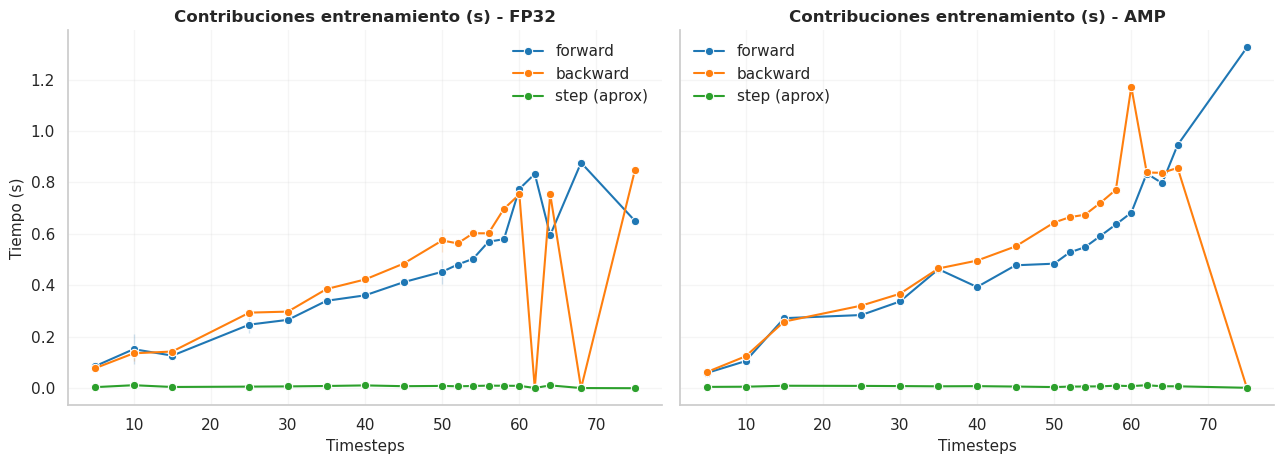

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, sharex=True)

for j, amp in enumerate([False, True]):
    sub = contrib_df[contrib_df["use_amp"] == amp]
    ax = axes[j]
    sns.lineplot(data=sub, x="timesteps", y="train_forward_s", marker="o", label="forward", color="#1f77b4", ax=ax)
    sns.lineplot(data=sub, x="timesteps", y="train_backward_s", marker="o", label="backward", color="#ff7f0e", ax=ax)
    sns.lineplot(data=sub, x="timesteps", y="train_step_s_calc", marker="o", label="step (aprox)", color="#2ca02c", ax=ax)
    ax.set_title(f"Contribuciones entrenamiento (s) - {AMP_LABELS[amp]}")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Tiempo (s)")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()


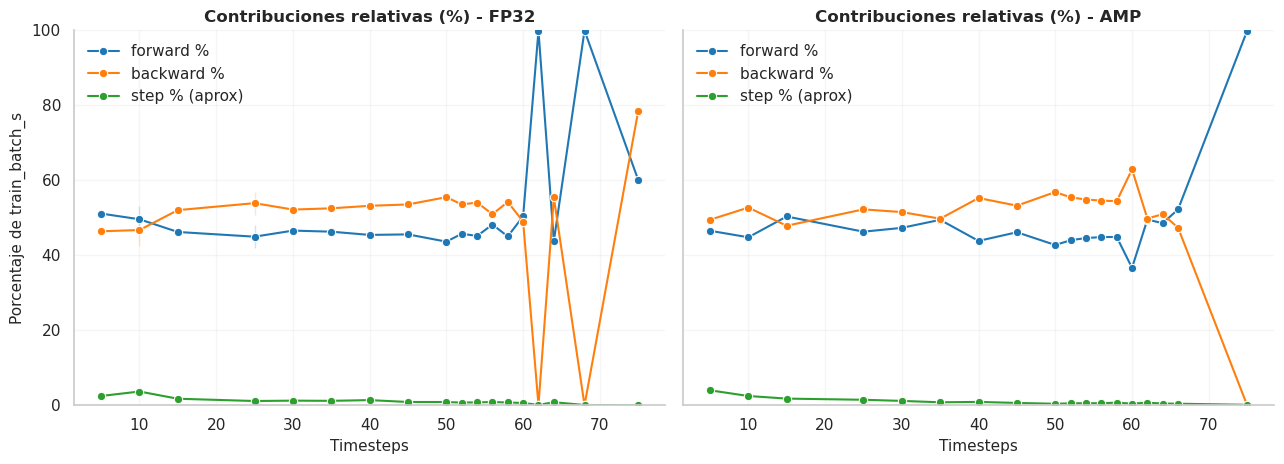

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, sharex=True)

for j, amp in enumerate([False, True]):
    sub = contrib_df[contrib_df["use_amp"] == amp]
    ax = axes[j]
    sns.lineplot(data=sub, x="timesteps", y="forward_pct", marker="o", label="forward %", color="#1f77b4", ax=ax)
    sns.lineplot(data=sub, x="timesteps", y="backward_pct", marker="o", label="backward %", color="#ff7f0e", ax=ax)
    sns.lineplot(data=sub, x="timesteps", y="step_pct", marker="o", label="step % (aprox)", color="#2ca02c", ax=ax)
    ax.set_title(f"Contribuciones relativas (%) - {AMP_LABELS[amp]}")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Porcentaje de train_batch_s")
    ax.set_ylim(0, 100)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()


In [139]:
cpu_gpu_train_df = df.dropna(
    subset=[
        "timesteps", "use_amp", "train_batch_s",
        "train_forward_cpu_s_keyavg", "train_forward_cuda_s_keyavg",
        "train_backward_cpu_s_keyavg", "train_backward_cuda_s_keyavg",
    ]
).copy()

cpu_gpu_train_df["train_cpu_total_s"] = (
    cpu_gpu_train_df["train_forward_cpu_s_keyavg"] + cpu_gpu_train_df["train_backward_cpu_s_keyavg"]
)
cpu_gpu_train_df["train_gpu_total_s"] = (
    cpu_gpu_train_df["train_forward_cuda_s_keyavg"] + cpu_gpu_train_df["train_backward_cuda_s_keyavg"]
)
cpu_gpu_train_df["train_cpu_gpu_total_s"] = (
    cpu_gpu_train_df["train_cpu_total_s"] + cpu_gpu_train_df["train_gpu_total_s"]
)

cpu_gpu_train_df["forward_cpu_pct"] = 100 * cpu_gpu_train_df["train_forward_cpu_s_keyavg"] / cpu_gpu_train_df["train_cpu_gpu_total_s"]
cpu_gpu_train_df["forward_gpu_pct"] = 100 * cpu_gpu_train_df["train_forward_cuda_s_keyavg"] / cpu_gpu_train_df["train_cpu_gpu_total_s"]
cpu_gpu_train_df["backward_cpu_pct"] = 100 * cpu_gpu_train_df["train_backward_cpu_s_keyavg"] / cpu_gpu_train_df["train_cpu_gpu_total_s"]
cpu_gpu_train_df["backward_gpu_pct"] = 100 * cpu_gpu_train_df["train_backward_cuda_s_keyavg"] / cpu_gpu_train_df["train_cpu_gpu_total_s"]

# Residual no atribuido por key-averages (incluye step + overhead/sync).
cpu_gpu_train_df["known_cpu_gpu_s"] = (
    cpu_gpu_train_df["train_forward_cpu_s_keyavg"]
    + cpu_gpu_train_df["train_forward_cuda_s_keyavg"]
    + cpu_gpu_train_df["train_backward_cpu_s_keyavg"]
    + cpu_gpu_train_df["train_backward_cuda_s_keyavg"]
)
cpu_gpu_train_df["step_plus_overhead_s"] = (
    cpu_gpu_train_df["train_batch_s"] - cpu_gpu_train_df["known_cpu_gpu_s"]
).clip(lower=0)

cpu_share = cpu_gpu_train_df["train_cpu_total_s"] / cpu_gpu_train_df["train_cpu_gpu_total_s"]
cpu_share = cpu_share.replace([np.inf, -np.inf], np.nan).fillna(0.5)
cpu_gpu_train_df["step_cpu_s_est"] = cpu_gpu_train_df["step_plus_overhead_s"] * cpu_share
cpu_gpu_train_df["step_gpu_s_est"] = cpu_gpu_train_df["step_plus_overhead_s"] * (1 - cpu_share)

cpu_gpu_train_df = cpu_gpu_train_df.replace([np.inf, -np.inf], np.nan)
cpu_gpu_train_df = cpu_gpu_train_df.sort_values(["use_amp", "timesteps"])


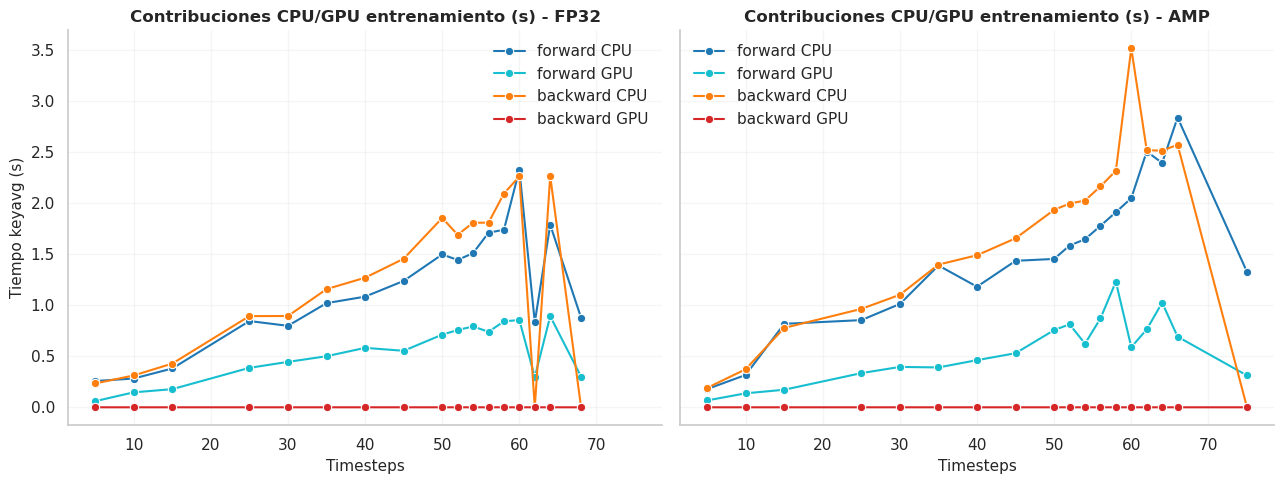

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), sharex=True, sharey=True)

for j, amp in enumerate([False, True]):
    sub = cpu_gpu_train_df[cpu_gpu_train_df["use_amp"] == amp]
    ax = axes[j]
    sns.lineplot(data=sub, x="timesteps", y="train_forward_cpu_s_keyavg", marker="o", label="forward CPU", color="#1f77b4", ax=ax)
    sns.lineplot(data=sub, x="timesteps", y="train_forward_cuda_s_keyavg", marker="o", label="forward GPU", color="#17becf", ax=ax)
    sns.lineplot(data=sub, x="timesteps", y="train_backward_cpu_s_keyavg", marker="o", label="backward CPU", color="#ff7f0e", ax=ax)
    sns.lineplot(data=sub, x="timesteps", y="train_backward_cuda_s_keyavg", marker="o", label="backward GPU", color="#d62728", ax=ax)
    ax.set_title(f"Contribuciones CPU/GPU entrenamiento (s) - {AMP_LABELS[amp]}")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Tiempo keyavg (s)")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()


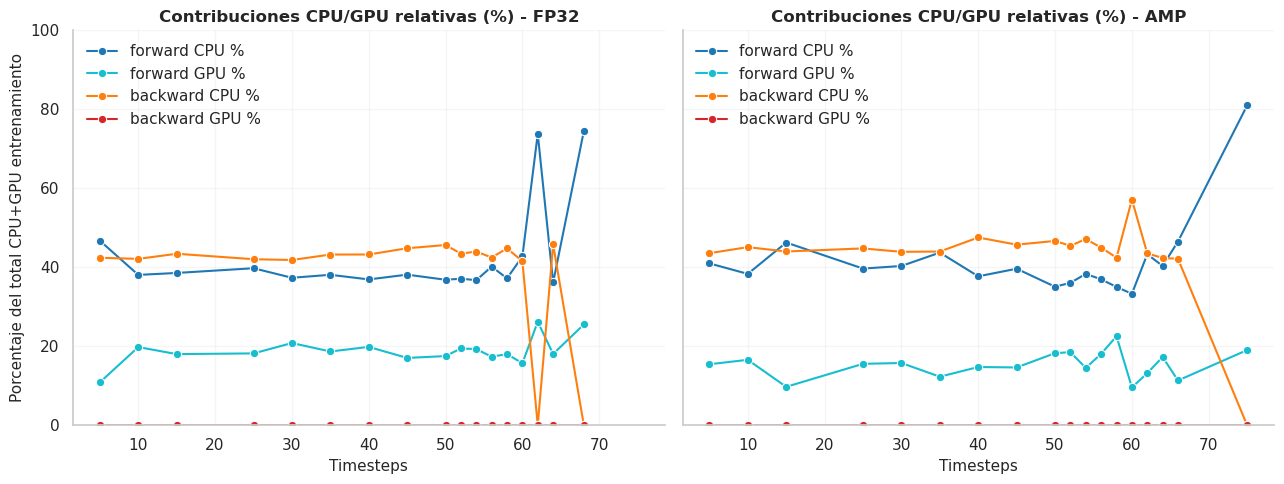

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), sharex=True, sharey=True)

for j, amp in enumerate([False, True]):
    sub = cpu_gpu_train_df[cpu_gpu_train_df["use_amp"] == amp]
    ax = axes[j]
    sns.lineplot(data=sub, x="timesteps", y="forward_cpu_pct", marker="o", label="forward CPU %", color="#1f77b4", ax=ax)
    sns.lineplot(data=sub, x="timesteps", y="forward_gpu_pct", marker="o", label="forward GPU %", color="#17becf", ax=ax)
    sns.lineplot(data=sub, x="timesteps", y="backward_cpu_pct", marker="o", label="backward CPU %", color="#ff7f0e", ax=ax)
    sns.lineplot(data=sub, x="timesteps", y="backward_gpu_pct", marker="o", label="backward GPU %", color="#d62728", ax=ax)
    ax.set_title(f"Contribuciones CPU/GPU relativas (%) - {AMP_LABELS[amp]}")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Porcentaje del total CPU+GPU entrenamiento")
    ax.set_ylim(0, 100)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()


### Alloc incremental por fase en GPU (delta promedio + delta peak)
Cada linea representa una fase (`forward`, `backward`, `step`) usando memoria incremental
respecto al inicio de la fase (`Total Allocated(t) - Total Allocated(t_inicio_fase)`).

- linea solida: delta promedio temporal en fase
- linea punteada: delta peak en fase

Layout: `AMP` izquierda, `FP32` derecha. Ejes: `x=timesteps`, `y=alloc incremental (MB)`.


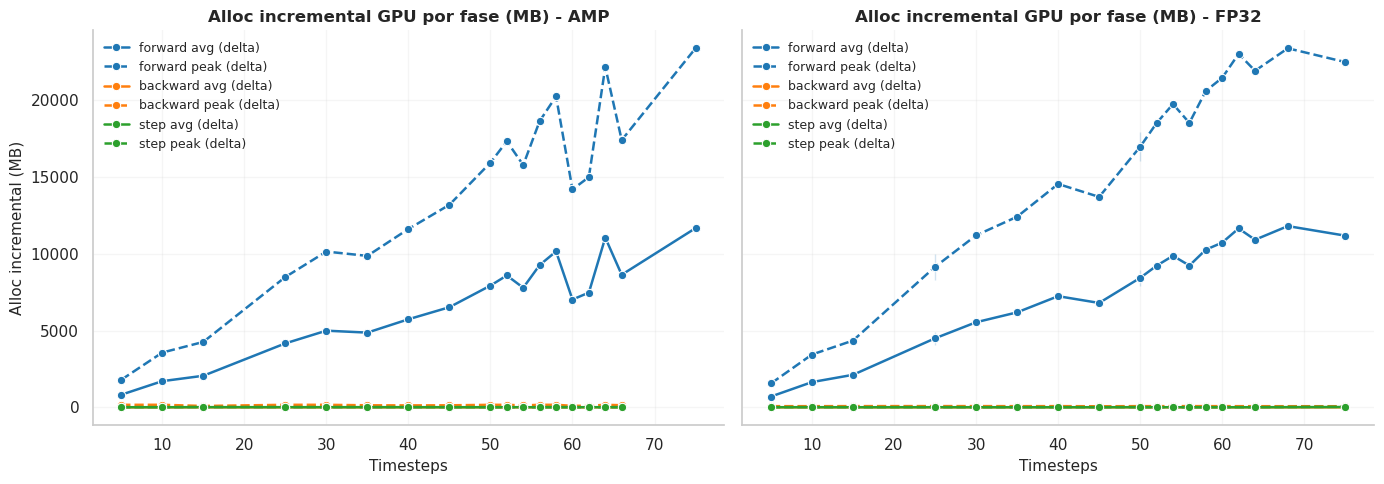

In [142]:
alloc_phase_cols = [
    "train_forward_alloc_avg_mb_gpu", "train_forward_alloc_peak_mb_gpu",
    "train_backward_alloc_avg_mb_gpu", "train_backward_alloc_peak_mb_gpu",
    "train_step_alloc_avg_mb_gpu", "train_step_alloc_peak_mb_gpu",
    "train_forward_alloc_avg_mb_cpu", "train_forward_alloc_peak_mb_cpu",
    "train_backward_alloc_avg_mb_cpu", "train_backward_alloc_peak_mb_cpu",
    "train_step_alloc_avg_mb_cpu", "train_step_alloc_peak_mb_cpu",
    "train_forward_alloc_delta_avg_mb_gpu", "train_forward_alloc_delta_peak_mb_gpu",
    "train_backward_alloc_delta_avg_mb_gpu", "train_backward_alloc_delta_peak_mb_gpu",
    "train_step_alloc_delta_avg_mb_gpu", "train_step_alloc_delta_peak_mb_gpu",
    "train_forward_alloc_delta_avg_mb_cpu", "train_forward_alloc_delta_peak_mb_cpu",
    "train_backward_alloc_delta_avg_mb_cpu", "train_backward_alloc_delta_peak_mb_cpu",
    "train_step_alloc_delta_avg_mb_cpu", "train_step_alloc_delta_peak_mb_cpu",
]
for c in alloc_phase_cols:
    if c not in df.columns:
        df[c] = np.nan

phase_defs = [
    ("train_forward", "forward", "#1f77b4"),
    ("train_backward", "backward", "#ff7f0e"),
    ("train_step", "step", "#2ca02c"),
]
agg_defs = [("avg", "-", "avg"), ("peak", "--", "peak")]

plot_df = df.dropna(subset=["timesteps", "use_amp"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharex=True, sharey=True)
for ax, amp in zip(axes, [True, False]):
    sub = plot_df[plot_df["use_amp"] == amp].sort_values("timesteps")

    for phase_key, phase_label, color in phase_defs:
        for agg_key, ls, agg_label in agg_defs:
            # Prefer delta metrics; fallback to total if delta not available.
            col = f"{phase_key}_alloc_delta_{agg_key}_mb_gpu"
            if col not in sub.columns or not sub[col].notna().any():
                col = f"{phase_key}_alloc_{agg_key}_mb_gpu"
            if col not in sub.columns or not sub[col].notna().any():
                continue

            label = f"{phase_label} {agg_label} (delta)" if "_delta_" in col else f"{phase_label} {agg_label}"
            sns.lineplot(
                data=sub,
                x="timesteps",
                y=col,
                marker="o",
                linewidth=1.8,
                linestyle=ls,
                color=color,
                label=label,
                ax=ax,
            )

    ax.set_title(f"Alloc incremental GPU por fase (MB) - {AMP_LABELS[amp]}")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Alloc incremental (MB)")
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()


### Alloc incremental por fase en CPU (delta promedio + delta peak)
Misma definicion incremental de lineas que en GPU, con escala propia para CPU.
Layout: `AMP` izquierda, `FP32` derecha. Ejes: `x=timesteps`, `y=alloc incremental (MB)`.


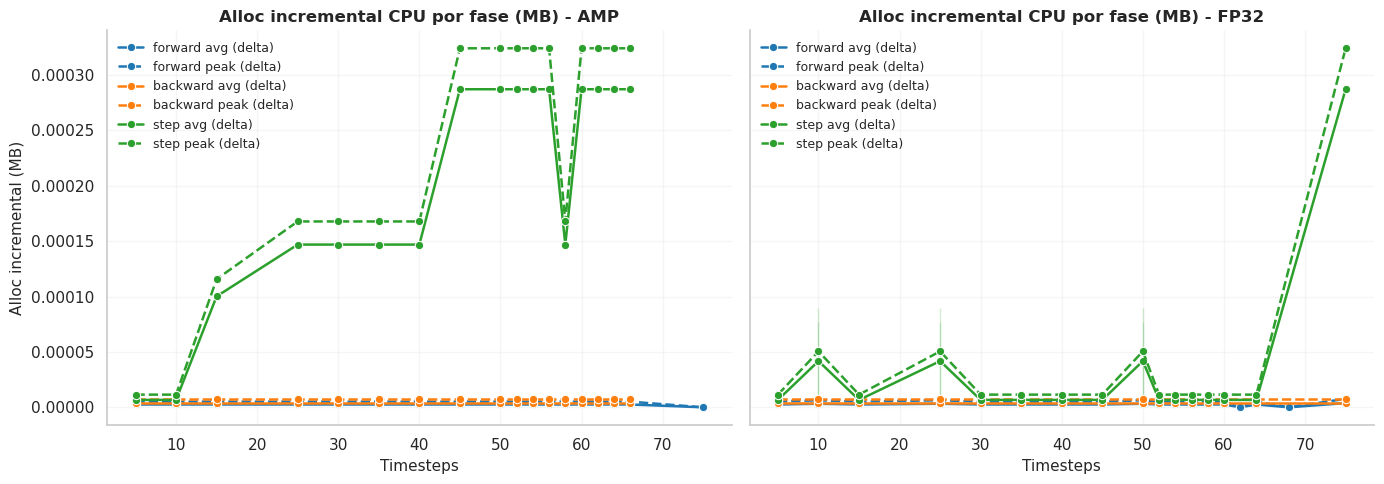

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.0), sharex=True, sharey=True)
for ax, amp in zip(axes, [True, False]):
    sub = plot_df[plot_df["use_amp"] == amp].sort_values("timesteps")

    for phase_key, phase_label, color in phase_defs:
        for agg_key, ls, agg_label in agg_defs:
            col = f"{phase_key}_alloc_delta_{agg_key}_mb_cpu"
            if col not in sub.columns or not sub[col].notna().any():
                col = f"{phase_key}_alloc_{agg_key}_mb_cpu"
            if col not in sub.columns or not sub[col].notna().any():
                continue

            label = f"{phase_label} {agg_label} (delta)" if "_delta_" in col else f"{phase_label} {agg_label}"
            sns.lineplot(
                data=sub,
                x="timesteps",
                y=col,
                marker="o",
                linewidth=1.8,
                linestyle=ls,
                color=color,
                label=label,
                ax=ax,
            )

    ax.set_title(f"Alloc incremental CPU por fase (MB) - {AMP_LABELS[amp]}")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Alloc incremental (MB)")
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()


In [144]:
cpu_cols = [
    "train_forward_cpu_s_keyavg", "train_forward_cuda_s_keyavg",
    "train_backward_cpu_s_keyavg", "train_backward_cuda_s_keyavg",
    "train_cpu_total_s", "train_gpu_total_s",
    "step_plus_overhead_s", "step_cpu_s_est", "step_gpu_s_est",
]

alloc_cols = [
    "train_forward_alloc_avg_mb_gpu", "train_forward_alloc_peak_mb_gpu",
    "train_backward_alloc_avg_mb_gpu", "train_backward_alloc_peak_mb_gpu",
    "train_step_alloc_avg_mb_gpu", "train_step_alloc_peak_mb_gpu",
    "train_forward_alloc_avg_mb_cpu", "train_forward_alloc_peak_mb_cpu",
    "train_backward_alloc_avg_mb_cpu", "train_backward_alloc_peak_mb_cpu",
    "train_step_alloc_avg_mb_cpu", "train_step_alloc_peak_mb_cpu",
    "train_forward_alloc_delta_avg_mb_gpu", "train_forward_alloc_delta_peak_mb_gpu",
    "train_backward_alloc_delta_avg_mb_gpu", "train_backward_alloc_delta_peak_mb_gpu",
    "train_step_alloc_delta_avg_mb_gpu", "train_step_alloc_delta_peak_mb_gpu",
    "train_forward_alloc_delta_avg_mb_cpu", "train_forward_alloc_delta_peak_mb_cpu",
    "train_backward_alloc_delta_avg_mb_cpu", "train_backward_alloc_delta_peak_mb_cpu",
    "train_step_alloc_delta_avg_mb_cpu", "train_step_alloc_delta_peak_mb_cpu",
]

contrib_cols = [
    "run_name", "timesteps", "use_amp",
    "train_batch_s", "train_forward_s", "train_backward_s", "train_step_s_calc",
    "forward_pct", "backward_pct", "step_pct",
    *cpu_cols,
    *alloc_cols,
]

out_df = contrib_df.copy()

missing_cpu_cols = [c for c in cpu_cols if c not in out_df.columns]
if missing_cpu_cols:
    out_df = out_df.merge(
        cpu_gpu_train_df[["run_name", "timesteps", "use_amp", *missing_cpu_cols]],
        on=["run_name", "timesteps", "use_amp"],
        how="left",
    )

missing_alloc_cols = [c for c in alloc_cols if c not in out_df.columns and c in df.columns]
if missing_alloc_cols:
    out_df = out_df.merge(
        df[["run_name", "timesteps", "use_amp", *missing_alloc_cols]].drop_duplicates(
            subset=["run_name", "timesteps", "use_amp"],
            keep="last",
        ),
        on=["run_name", "timesteps", "use_amp"],
        how="left",
    )

for c in contrib_cols:
    if c not in out_df.columns:
        out_df[c] = np.nan

display(out_df[contrib_cols].sort_values(["timesteps", "use_amp"], na_position="last"))


,run_name,timesteps,use_amp,train_batch_s,train_forward_s,train_backward_s,train_step_s_calc,forward_pct,backward_pct,step_pct,...,train_backward_alloc_delta_avg_mb_gpu,train_backward_alloc_delta_peak_mb_gpu,train_step_alloc_delta_avg_mb_gpu,train_step_alloc_delta_peak_mb_gpu,train_forward_alloc_delta_avg_mb_cpu,train_forward_alloc_delta_peak_mb_cpu,train_backward_alloc_delta_avg_mb_cpu,train_backward_alloc_delta_peak_mb_cpu,train_step_alloc_delta_avg_mb_cpu,train_step_alloc_delta_peak_mb_cpu
0,sim90_bs4_pb4_5ts_fp32,5,False,0.167672,0.085724,0.077808,0.004140,51.125707,46.404992,2.469300,...,0.411274,74.346517,5.657608,11.049805,0.000003,0.000005,0.000004,0.000008,0.000007,0.000011
21,sim90_bs4_pb4_5ts_amp,5,True,0.127686,0.059427,0.063170,0.005089,46.541255,49.472926,3.985819,...,0.285104,161.813639,5.583212,11.540690,0.000003,0.000005,0.000004,0.000008,0.000007,0.000011
1,sim90_bs4_pb4_10ts,10,False,0.394764,0.209729,0.167574,0.017461,53.127695,42.449213,4.423091,...,0.219162,71.034668,8.953687,16.263672,0.000004,0.000008,0.000004,0.000008,0.000077,0.000090
2,sim90_bs4_pb4_10ts_fp32,10,False,0.203681,0.093878,0.103887,0.005917,46.090462,51.004674,2.904864,...,0.255133,76.250977,5.910335,11.532227,0.000003,0.000005,0.000004,0.000008,0.000007,0.000011
22,sim90_bs4_pb4_10ts_amp,10,True,0.235426,0.105477,0.124130,0.005819,44.802677,52.725772,2.471552,...,0.146769,163.297038,5.562819,11.469727,0.000003,0.000005,0.000004,0.000008,0.000007,0.000011
3,sim90_bs4_pb4_15ts_fp32,15,False,0.274095,0.126684,0.142644,0.004768,46.218890,52.041689,1.739421,...,0.137325,77.340332,5.549294,10.862142,0.000003,0.000005,0.000004,0.000008,0.000007,0.000011
23,sim90_bs4_pb4_15ts_amp,15,True,0.540934,0.272355,0.259000,0.009579,50.348995,47.880116,1.770889,...,0.075621,87.364421,10.154995,18.696126,0.000003,0.000005,0.000004,0.000008,0.000100,0.000116
4,sim90_bs4_pb4_25ts,25,False,0.509018,0.213083,0.290100,0.005835,41.861527,56.992147,1.146326,...,0.091803,75.821411,8.963204,16.213013,0.000004,0.000008,0.000004,0.000008,0.000077,0.000090
5,sim90_bs4_pb4_25ts_fp32,25,False,0.585557,0.281428,0.297599,0.006530,48.061560,50.823205,1.115235,...,0.105127,82.397135,5.584020,10.995768,0.000003,0.000005,0.000004,0.000008,0.000007,0.000011
24,sim90_bs4_pb4_25ts_amp,25,True,0.614622,0.284513,0.321123,0.008986,46.290728,52.247235,1.462037,...,0.059354,162.543294,7.992016,14.551432,0.000003,0.000005,0.000004,0.000008,0.000147,0.000168
